# OpenAlex Topics Analysis

This notebook analyzes the distribution of topics per author from the OpenAlex dataset stored in Azure Cosmos DB.

## Import Required Libraries

In [17]:
import os
from azure.cosmos import CosmosClient
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## Connect to Cosmos DB

Set up your connection string and database/container names.

In [18]:
# Cosmos DB Configuration
COSMOS_ENDPOINT = os.getenv("COSMOS_ENDPOINT", "https://aegiscosmosdb.documents.azure.com")
COSMOS_KEY = os.getenv("COSMOS_KEY", "6Di3nSl2nSG7qitzD8SGYeXuw5rn3eUmC4fha2YswtM5R5hSet8u0hYzMMSnhVBmTfNgMJMxKAbTACDbSPsJpg==")
DATABASE_NAME = "aegisraw"  # Update with your database name
CONTAINER_NAME = "openalex-works"  # Update with your container name

# Initialize Cosmos client
client = CosmosClient(COSMOS_ENDPOINT, COSMOS_KEY)
database = client.get_database_client(DATABASE_NAME)
container = database.get_container_client(CONTAINER_NAME)

print(f"Connected to database: {DATABASE_NAME}, container: {CONTAINER_NAME}")

Connected to database: aegisraw, container: openalex-works


## Query and Load Data

Query documents from Cosmos DB. We'll fetch documents with topics and authorships information.

In [19]:
# Query documents with topics and authors
# Adjust the query based on your needs (you may want to limit results for initial exploration)
query = """
SELECT c.id, c.title, c.authorships, c.topics, c.primary_topic
FROM c
WHERE IS_DEFINED(c.topics) AND ARRAY_LENGTH(c.topics) > 0
AND IS_DEFINED(c.authorships) AND ARRAY_LENGTH(c.authorships) > 0
"""

# Fetch documents (limit to first batch for exploration)
items = list(container.query_items(
    query=query,
    enable_cross_partition_query=True,
    max_item_count=1000  # Adjust this based on your needs
))

print(f"Fetched {len(items)} documents")

Fetched 839785 documents


## Extract and Prepare Data

Extract author and topic information from the documents.

In [20]:
# Extract author-topic relationships
author_topics = defaultdict(list)  # {author_id: [list of topics]}
author_names = {}  # {author_id: author_name}
author_paper_counts = defaultdict(int)  # {author_id: number of papers}

for item in items:
    # Extract topics for this paper
    paper_topics = []
    if item.get('topics'):
        for topic in item['topics']:
            if topic.get('id'):
                paper_topics.append({
                    'id': topic['id'],
                    'display_name': topic.get('display_name', 'Unknown'),
                    'score': topic.get('score', 0)
                })
    
    # Extract authors and link to topics
    if item.get('authorships'):
        for authorship in item['authorships']:
            author = authorship.get('author', {})
            author_id = author.get('id')
            author_name = author.get('display_name', 'Unknown')
            
            if author_id:
                # Store author name
                author_names[author_id] = author_name
                
                # Count papers
                author_paper_counts[author_id] += 1
                
                # Associate topics with this author
                for topic in paper_topics:
                    author_topics[author_id].append(topic)

print(f"Processed {len(author_names)} unique authors")
print(f"Total author-topic associations: {sum(len(topics) for topics in author_topics.values())}")

Processed 1253194 unique authors
Total author-topic associations: 3638672


## Analyze Topics Per Author

Calculate statistics on the number of topics per author.

In [21]:
# Calculate unique topics per author
author_unique_topics = {}
author_topic_diversity = {}

for author_id, topics in author_topics.items():
    # Get unique topics
    unique_topic_ids = set(topic['id'] for topic in topics)
    author_unique_topics[author_id] = len(unique_topic_ids)
    
    # Calculate topic diversity (number of unique topics / total papers)
    author_topic_diversity[author_id] = len(unique_topic_ids) / author_paper_counts[author_id]

# Create a DataFrame for analysis
author_stats_df = pd.DataFrame({
    'author_id': list(author_names.keys()),
    'author_name': [author_names[aid] for aid in author_names.keys()],
    'num_papers': [author_paper_counts[aid] for aid in author_names.keys()],
    'total_topics': [len(author_topics[aid]) for aid in author_names.keys()],
    'unique_topics': [author_unique_topics[aid] for aid in author_names.keys()],
    'topic_diversity': [author_topic_diversity[aid] for aid in author_names.keys()]
})

# Sort by number of papers
author_stats_df = author_stats_df.sort_values('num_papers', ascending=False)

print("\nAuthor Statistics Summary:")
print(author_stats_df[['num_papers', 'unique_topics', 'topic_diversity']].describe())
print("\nTop 10 authors by number of papers:")
print(author_stats_df[['author_name', 'num_papers', 'unique_topics', 'topic_diversity']].head(10))


Author Statistics Summary:
         num_papers  unique_topics  topic_diversity
count  1.253194e+06   1.253194e+06     1.253194e+06
mean   1.260980e+00   2.723209e+00     2.249088e+00
std    1.117070e+00   1.855040e+00     8.435303e-01
min    1.000000e+00   1.000000e+00     1.428571e-01
25%    1.000000e+00   2.000000e+00     1.000000e+00
50%    1.000000e+00   3.000000e+00     3.000000e+00
75%    1.000000e+00   3.000000e+00     3.000000e+00
max    1.400000e+02   1.590000e+02     3.000000e+00

Top 10 authors by number of papers:
                           author_name  num_papers  unique_topics  \
24333                     Nelios media         140             87   
21546                       Quim Casas         137            117   
20491                     Stijn Vogels         118            159   
20411   Fernando López Lerdo de Tejada          99             41   
21892                 H. Oroz Zabaleta          97            128   
34907                  Enrico Reggiani          87   

## Visualize Topic Distribution

Create visualizations to understand topic distribution patterns.

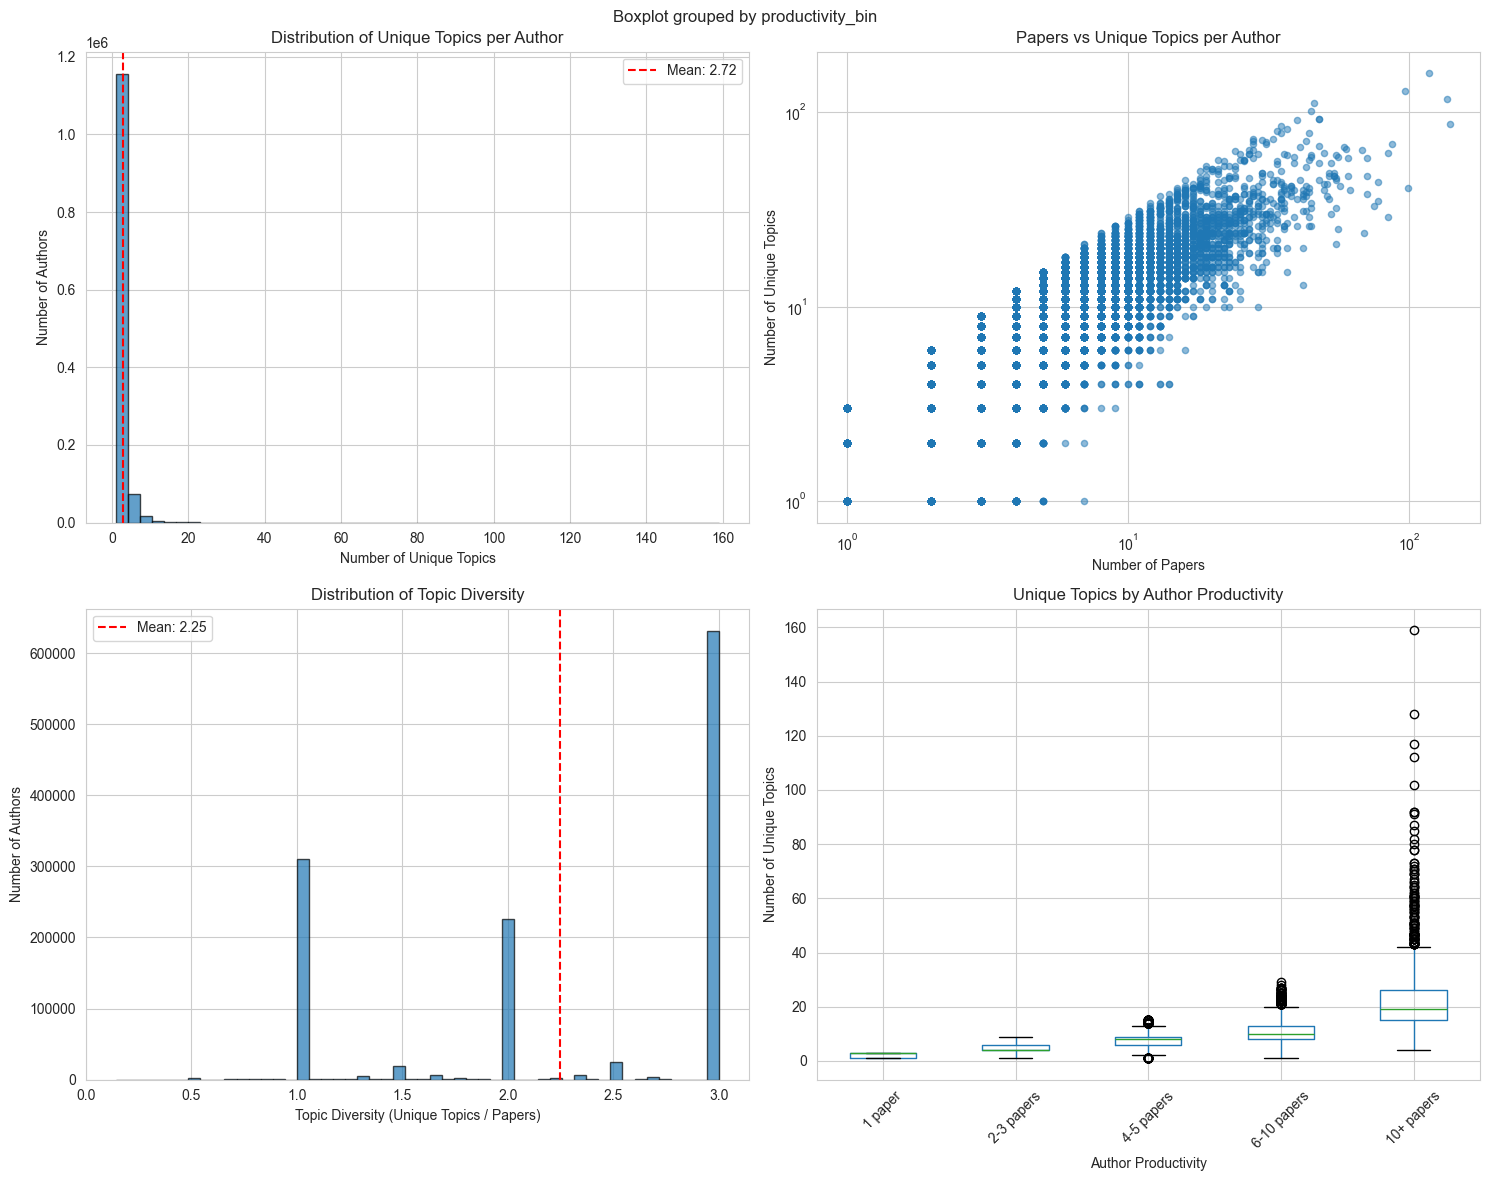

In [22]:
# Distribution of unique topics per author
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Histogram of unique topics per author
axes[0, 0].hist(author_stats_df['unique_topics'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Number of Unique Topics')
axes[0, 0].set_ylabel('Number of Authors')
axes[0, 0].set_title('Distribution of Unique Topics per Author')
axes[0, 0].axvline(author_stats_df['unique_topics'].mean(), color='red', 
                    linestyle='--', label=f"Mean: {author_stats_df['unique_topics'].mean():.2f}")
axes[0, 0].legend()

# 2. Scatter plot: Papers vs Unique Topics
axes[0, 1].scatter(author_stats_df['num_papers'], author_stats_df['unique_topics'], 
                   alpha=0.5, s=20)
axes[0, 1].set_xlabel('Number of Papers')
axes[0, 1].set_ylabel('Number of Unique Topics')
axes[0, 1].set_title('Papers vs Unique Topics per Author')
axes[0, 1].set_xscale('log')
axes[0, 1].set_yscale('log')

# 3. Topic diversity distribution
axes[1, 0].hist(author_stats_df['topic_diversity'], bins=50, edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Topic Diversity (Unique Topics / Papers)')
axes[1, 0].set_ylabel('Number of Authors')
axes[1, 0].set_title('Distribution of Topic Diversity')
axes[1, 0].axvline(author_stats_df['topic_diversity'].mean(), color='red', 
                    linestyle='--', label=f"Mean: {author_stats_df['topic_diversity'].mean():.2f}")
axes[1, 0].legend()

# 4. Box plot of topics by author productivity bins
author_stats_df['productivity_bin'] = pd.cut(author_stats_df['num_papers'], 
                                               bins=[0, 1, 3, 5, 10, float('inf')],
                                               labels=['1 paper', '2-3 papers', '4-5 papers', 
                                                      '6-10 papers', '10+ papers'])
author_stats_df.boxplot(column='unique_topics', by='productivity_bin', ax=axes[1, 1])
axes[1, 1].set_xlabel('Author Productivity')
axes[1, 1].set_ylabel('Number of Unique Topics')
axes[1, 1].set_title('Unique Topics by Author Productivity')
plt.sca(axes[1, 1])
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

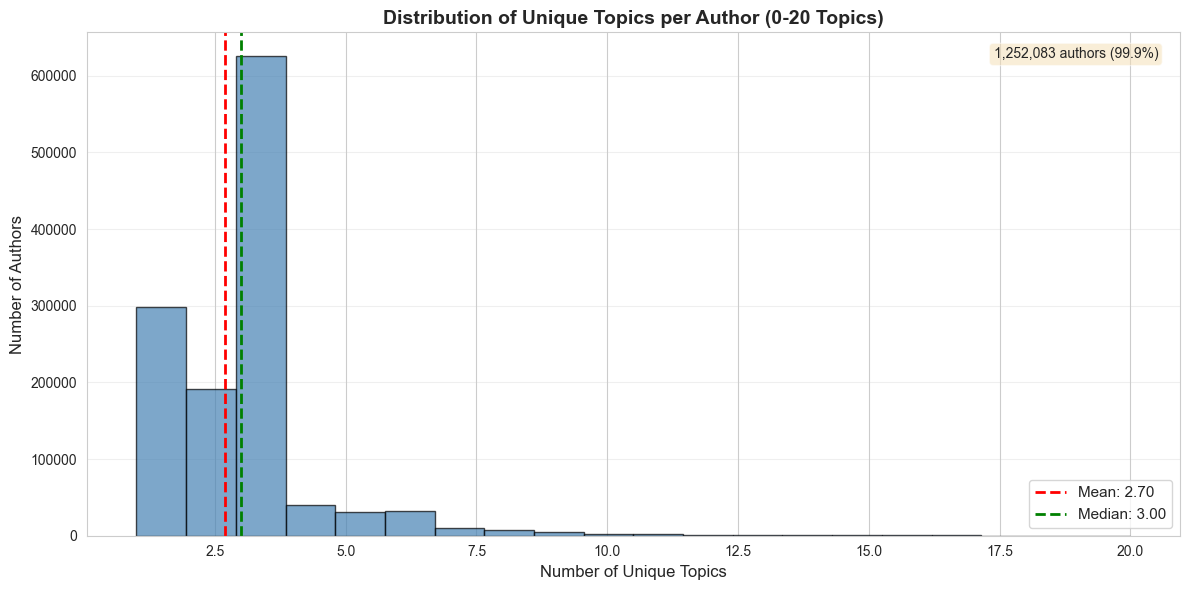


Authors with 0-20 unique topics: 1,252,083 (99.9%)
Authors with >20 unique topics: 1,111 (0.1%)


In [27]:
# Zoomed-in view of unique topics distribution (0-20 topics)
plt.figure(figsize=(12, 6))

# Filter data for 0-20 range
filtered_data = author_stats_df[author_stats_df['unique_topics'] <= 20]['unique_topics']

plt.hist(filtered_data, bins=20, edgecolor='black', alpha=0.7, color='steelblue')
plt.xlabel('Number of Unique Topics', fontsize=12)
plt.ylabel('Number of Authors', fontsize=12)
plt.title('Distribution of Unique Topics per Author (0-20 Topics)', fontsize=14, fontweight='bold')
plt.axvline(filtered_data.mean(), color='red', linestyle='--', linewidth=2, 
            label=f'Mean: {filtered_data.mean():.2f}')
plt.axvline(filtered_data.median(), color='green', linestyle='--', linewidth=2, 
            label=f'Median: {filtered_data.median():.2f}')
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3)

# Add count annotation
total_in_range = len(filtered_data)
pct_in_range = (total_in_range / len(author_stats_df)) * 100
plt.text(0.98, 0.97, f'{total_in_range:,} authors ({pct_in_range:.1f}%)', 
         transform=plt.gca().transAxes, fontsize=10, verticalalignment='top',
         horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print(f"\nAuthors with 0-20 unique topics: {total_in_range:,} ({pct_in_range:.1f}%)")
print(f"Authors with >20 unique topics: {len(author_stats_df) - total_in_range:,} ({100-pct_in_range:.1f}%)")

## Most Common Topics

Identify the most common topics across all authors.

In [28]:
# Find the author with the most unique topics
author_with_most_topics = author_stats_df.nlargest(1, 'unique_topics')

print("Author with the Most Unique Topics:")
print("=" * 60)
print(f"Name: {author_with_most_topics['author_name'].values[0]}")
print(f"Unique Topics: {author_with_most_topics['unique_topics'].values[0]}")
print(f"Number of Papers: {author_with_most_topics['num_papers'].values[0]}")
print(f"Topic Diversity: {author_with_most_topics['topic_diversity'].values[0]:.2f}")
print(f"Author ID: {author_with_most_topics['author_id'].values[0]}")

# Show top 10 authors by unique topics
print("\n\nTop 10 Authors by Unique Topics:")
print("=" * 60)
top_10_by_topics = author_stats_df.nlargest(10, 'unique_topics')[['author_name', 'unique_topics', 'num_papers', 'topic_diversity']]
print(top_10_by_topics.to_string(index=False))

Author with the Most Unique Topics:
Name: Stijn Vogels
Unique Topics: 159
Number of Papers: 118
Topic Diversity: 1.35
Author ID: https://openalex.org/A5056798463


Top 10 Authors by Unique Topics:
     author_name  unique_topics  num_papers  topic_diversity
    Stijn Vogels            159         118         1.347458
H. Oroz Zabaleta            128          97         1.319588
      Quim Casas            117         137         0.854015
           LU LU            112          46         2.434783
             Wei            102          45         2.266667
           Zhang             92          48         1.916667
              Li             92          48         1.916667
         Jie Jie             91          40         2.275000
    Nelios media             87         140         0.621429
         ■ Xiang             85          35         2.428571


Top 20 Most Common Topics:
                                           topic_name  count
0   Particle physics theoretical and experimental ...  40290
1            High-Energy Particle Collisions Research  35431
2    Quantum Chromodynamics and Particle Interactions  22596
3               Archaeological and Historical Studies  22084
4                        Social Sciences and Policies  19985
5                   Finance, Taxation, and Governance  13601
6                    Nuclear Physics and Applications  12758
7               Medieval Architecture and Archaeology  12310
8   Historical and socio-economic studies of Spain...  11894
9       Particle Detector Development and Performance  11792
10            Historical Art and Architecture Studies  11556
11                       Human Rights and Immigration  10943
12             Spanish Literature and Culture Studies  10865
13            Comparative International Legal Studies  10699
14              Employment, Labor, and Gender Studies   98

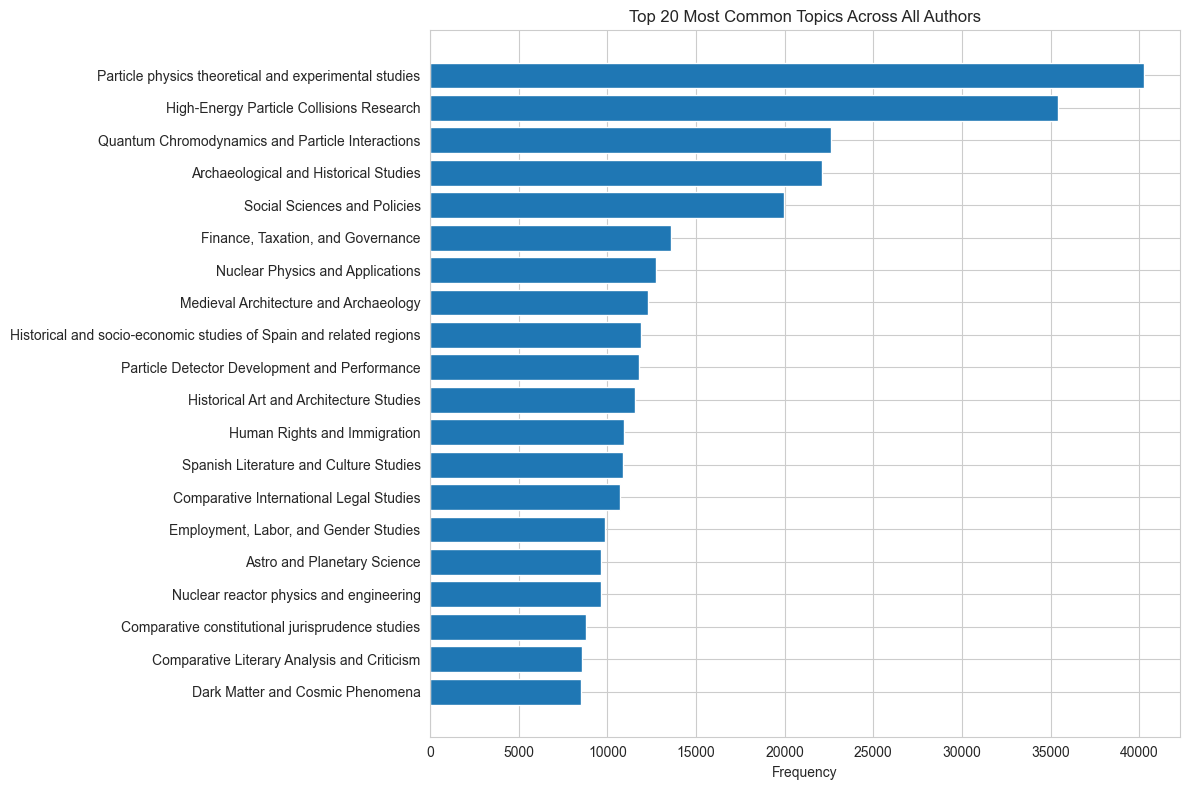

In [23]:
# Count all topics
all_topics = []
for topics in author_topics.values():
    for topic in topics:
        all_topics.append((topic['id'], topic['display_name']))

topic_counter = Counter(all_topics)
top_topics = topic_counter.most_common(20)

# Create DataFrame for top topics
top_topics_df = pd.DataFrame(top_topics, columns=['topic', 'count'])
top_topics_df['topic_name'] = top_topics_df['topic'].apply(lambda x: x[1])
top_topics_df['topic_id'] = top_topics_df['topic'].apply(lambda x: x[0])

print("Top 20 Most Common Topics:")
print(top_topics_df[['topic_name', 'count']])

# Visualize top topics
plt.figure(figsize=(12, 8))
plt.barh(range(len(top_topics_df)), top_topics_df['count'])
plt.yticks(range(len(top_topics_df)), top_topics_df['topic_name'])
plt.xlabel('Frequency')
plt.title('Top 20 Most Common Topics Across All Authors')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Check for Authors with No Topics

Query for works that have authors but no topics to identify authors with zero topics.

In [ ]:
# Query for works with authors but no topics
query_no_topics = """
SELECT c.id, c.authorships
FROM c
WHERE IS_DEFINED(c.authorships) AND ARRAY_LENGTH(c.authorships) > 0
AND (NOT IS_DEFINED(c.topics) OR ARRAY_LENGTH(c.topics) = 0)
"""

# Fetch documents without topics
items_no_topics = list(container.query_items(
    query=query_no_topics,
    enable_cross_partition_query=True,
    max_item_count=1000
))
print(f"Fetched {len(items_no_topics):,} documents with authors but no topics")

In [31]:
# Extract authors from these works
authors_without_topics = set()
for item in items_no_topics:
    if item.get('authorships'):
        for authorship in item['authorships']:
            author = authorship.get('author', {})
            author_id = author.get('id')
            if author_id:
                authors_without_topics.add(author_id)

print(f"Found {len(authors_without_topics):,} unique authors in works without topics")

# Check how many of these authors ONLY appear in works without topics
# (i.e., they have zero topics across all their papers)
authors_with_topics_set = set(author_names.keys())
authors_only_without_topics = authors_without_topics - authors_with_topics_set

print(f"\nAuthors with ZERO topics (only in works without topics): {len(authors_only_without_topics):,}")
print(f"Authors who have SOME works with topics: {len(authors_without_topics & authors_with_topics_set):,}")

Found 542,357 unique authors in works without topics

Authors with ZERO topics (only in works without topics): 516,160
Authors who have SOME works with topics: 26,197


## Author Topic Specialization

Analyze how specialized authors are in their topics.

In [24]:
# Calculate total unique topics across all papers
unique_topics_count = len(topic_counter)
print(f"\n{'='*60}")
print(f"Total Unique Topics Across All Papers: {unique_topics_count:,}")
print(f"{'='*60}")
print(f"\nTotal papers analyzed: {len(items):,}")
print(f"Total topic occurrences: {sum(topic_counter.values()):,}")
print(f"Average topics per paper: {sum(topic_counter.values()) / len(items):.2f}")


Total Unique Topics Across All Papers: 4,508

Total papers analyzed: 839,785
Total topic occurrences: 3,638,672
Average topics per paper: 4.33



Topic Concentration Statistics:
count    1.253194e+06
mean     5.026268e-01
std      2.891417e-01
min      9.215220e-03
25%      3.333333e-01
50%      3.333333e-01
75%      5.000000e-01
max      1.000000e+00
Name: topic_concentration, dtype: float64

Most Specialized Authors (with 3+ papers):
                         author_name  num_papers  unique_topics  \
38920                 William Sadler           7              1   
6819                        M. Smith           5              1   
87167         Andreu Domingo i Valls           5              1   
191238                Russell Street           5              1   
191239                     Melbourne           5              1   
112019               Caroline Liberg           5              1   
892760                           윤영빈           4              1   
43452          Pilar Vieiro Iglesias           4              1   
90079   María del Carmen de la Plaza           4              1   
90080      Alberto Arriba Balenciag

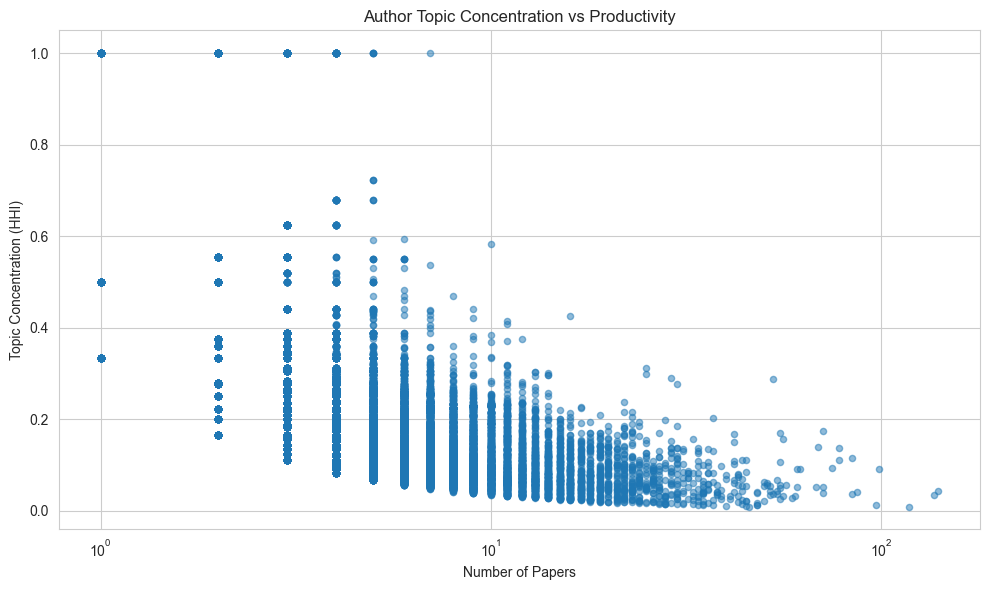

In [25]:
# Calculate topic concentration for each author
# Using Herfindahl-Hirschman Index (HHI) - higher values = more concentrated/specialized

def calculate_hhi(topics_list):
    """Calculate HHI for topic distribution"""
    if not topics_list:
        return 0
    
    # Count topic occurrences
    topic_counts = Counter(topic['id'] for topic in topics_list)
    total = len(topics_list)
    
    # Calculate HHI
    hhi = sum((count / total) ** 2 for count in topic_counts.values())
    return hhi

author_stats_df['topic_concentration'] = author_stats_df['author_id'].apply(
    lambda aid: calculate_hhi(author_topics[aid])
)

# Authors with single-topic focus have HHI = 1, diverse authors have lower HHI
print("\nTopic Concentration Statistics:")
print(author_stats_df['topic_concentration'].describe())

# Find most specialized authors (high HHI, multiple papers)
specialized_authors = author_stats_df[author_stats_df['num_papers'] >= 3].nlargest(10, 'topic_concentration')
print("\nMost Specialized Authors (with 3+ papers):")
print(specialized_authors[['author_name', 'num_papers', 'unique_topics', 'topic_concentration']])

# Find most diverse authors (low HHI, multiple papers)
diverse_authors = author_stats_df[author_stats_df['num_papers'] >= 3].nsmallest(10, 'topic_concentration')
print("\nMost Diverse Authors (with 3+ papers):")
print(diverse_authors[['author_name', 'num_papers', 'unique_topics', 'topic_concentration']])

# Visualize concentration vs diversity
plt.figure(figsize=(10, 6))
plt.scatter(author_stats_df['num_papers'], author_stats_df['topic_concentration'], 
            alpha=0.5, s=20)
plt.xlabel('Number of Papers')
plt.ylabel('Topic Concentration (HHI)')
plt.title('Author Topic Concentration vs Productivity')
plt.xscale('log')
plt.tight_layout()
plt.show()